In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import importlib
import methods
importlib.reload(methods)
from methods import ETL
from prophet import Prophet
from sklearn.metrics import mean_squared_error, r2_score

In [34]:
#Set your variables
csv_filename = 'eia_retail_sales_mwh_monthly_state_sectorwide.csv'
path = r'C:\Users\TobyWong\Desktop\UNCC\5122\EIA_end_customer_sales_power_prediction_NC\data'
stateid = 'NC'
drop_columns = ['ALL', 'OTH', 'RES', 'TRA','IND']
keep_columns = ['COM']

In [35]:
df = ETL(
    csv_filename=csv_filename,
    os_path=path,
    stateid=stateid,
    drop_columns=drop_columns,
    keep_columns=keep_columns
)
df.head(1)

,period,stateid,COM,salesUnit
31,2025-11-01,NC,3730.97423,million kilowatt hours


19:07:59 - cmdstanpy - INFO - Chain [1] start processing
19:07:59 - cmdstanpy - INFO - Chain [1] done processing
19:07:59 - cmdstanpy - INFO - Chain [1] start processing
19:07:59 - cmdstanpy - INFO - Chain [1] done processing


Test RMSE: 217.2731733556542
Test R^2: 0.7825181828997356
        period stateid               salesUnit  predicted_COM
299 2025-12-01      NC  million kilowatt hours    3830.730627
300 2026-01-01      NC  million kilowatt hours    4082.776686
301 2026-02-01      NC  million kilowatt hours    3701.581533
302 2026-03-01      NC  million kilowatt hours    3771.757863
303 2026-04-01      NC  million kilowatt hours    3754.847261
304 2026-05-01      NC  million kilowatt hours    4083.364794
305 2026-06-01      NC  million kilowatt hours    4442.920680
306 2026-07-01      NC  million kilowatt hours    4808.794596
307 2026-08-01      NC  million kilowatt hours    4823.290599
308 2026-09-01      NC  million kilowatt hours    4498.967369
309 2026-10-01      NC  million kilowatt hours    4100.622872
310 2026-11-01      NC  million kilowatt hours    3795.168319
311 2026-12-01      NC  million kilowatt hours    3879.667133
312 2027-01-01      NC  million kilowatt hours    4066.091385
313 2027-02-

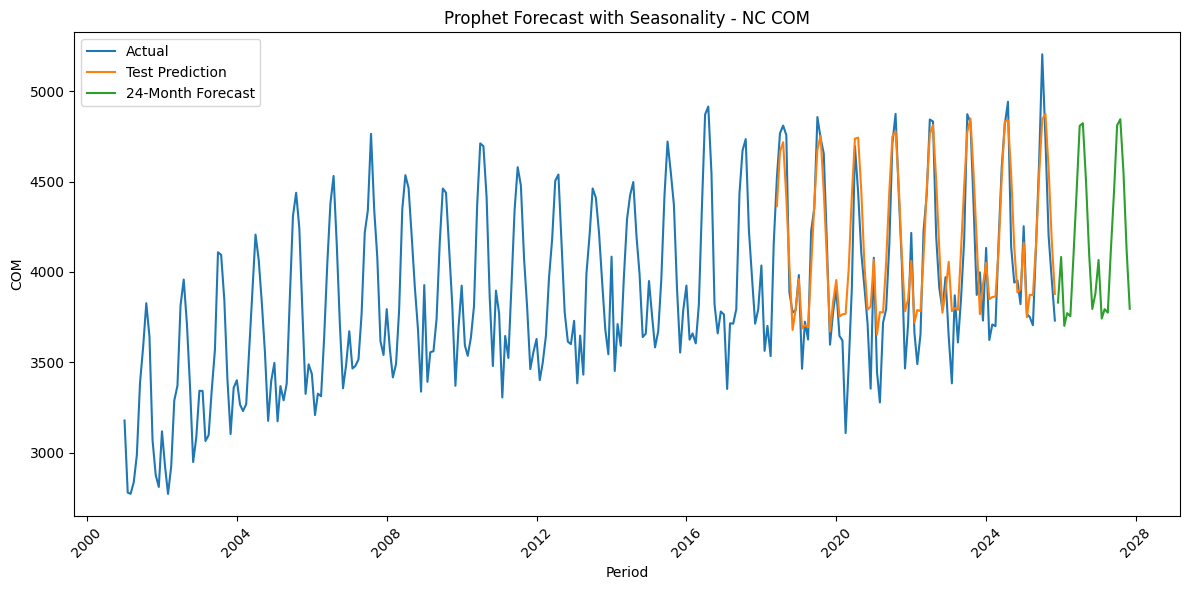

In [43]:
target_col = keep_columns[0]

# version 1
df_model = df.copy()
df_model["period"] = pd.to_datetime(df_model["period"])
df_model = df_model.sort_values("period").reset_index(drop=True)

prophet_df = df_model[["period", target_col]].rename(columns={"period": "ds", target_col: "y"})

# Train/test split (70/30)
split_idx = int(len(prophet_df) * 0.7)
train = prophet_df.iloc[:split_idx].copy()
test = prophet_df.iloc[split_idx:].copy()

# Fit Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive"
)
model.fit(train)

# Predict on test set
test_forecast = model.predict(test[["ds"]])
test[f"predicted_{target_col}"] = test_forecast["yhat"].values

# Metrics
rmse = np.sqrt(mean_squared_error(test["y"], test[f"predicted_{target_col}"]))
r2 = r2_score(test["y"], test[f"predicted_{target_col}"])

print("Test RMSE:", rmse)
print("Test R^2:", r2)

# Refit on full dataset for 24-month forecast
final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive"
)
final_model.fit(prophet_df)

future = final_model.make_future_dataframe(periods=24, freq="MS")
forecast = final_model.predict(future)

future_forecast = forecast[forecast["ds"] > prophet_df["ds"].max()][["ds", "yhat"]].copy()
future_forecast = future_forecast.rename(
    columns={"ds": "period", "yhat": f"predicted_{target_col}"}
)
future_forecast["stateid"] = stateid
future_forecast["salesUnit"] = "million kilowatt hours"

print(future_forecast[["period", "stateid", "salesUnit", f"predicted_{target_col}"]])

# Plot
plt.figure(figsize=(12, 6))
plt.plot(prophet_df["ds"], prophet_df["y"], label="Actual")
plt.plot(test["ds"], test[f"predicted_{target_col}"], label="Test Prediction")
plt.plot(
    future_forecast["period"],
    future_forecast[f"predicted_{target_col}"],
    label="24-Month Forecast"
)
plt.xlabel("Period")
plt.ylabel(target_col)
plt.title(f"Prophet Forecast with Seasonality - {stateid} {target_col}")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

19:08:21 - cmdstanpy - INFO - Chain [1] start processing
19:08:21 - cmdstanpy - INFO - Chain [1] done processing
19:08:22 - cmdstanpy - INFO - Chain [1] start processing
19:08:22 - cmdstanpy - INFO - Chain [1] done processing


Test RMSE: 217.2731733556542
Test R^2: 0.7825181828997356
        period stateid               salesUnit  predicted_COM
299 2025-12-01      NC  million kilowatt hours    3837.464698
300 2026-01-01      NC  million kilowatt hours    4111.521470
301 2026-02-01      NC  million kilowatt hours    3692.904588
302 2026-03-01      NC  million kilowatt hours    3776.181732
303 2026-04-01      NC  million kilowatt hours    3754.874777
304 2026-05-01      NC  million kilowatt hours    4113.871883
305 2026-06-01      NC  million kilowatt hours    4504.896554
306 2026-07-01      NC  million kilowatt hours    4901.675291
307 2026-08-01      NC  million kilowatt hours    4914.357693
308 2026-09-01      NC  million kilowatt hours    4562.810860
309 2026-10-01      NC  million kilowatt hours    4134.591637
310 2026-11-01      NC  million kilowatt hours    3808.571347
311 2026-12-01      NC  million kilowatt hours    3900.366311
312 2027-01-01      NC  million kilowatt hours    4102.767539
313 2027-02-

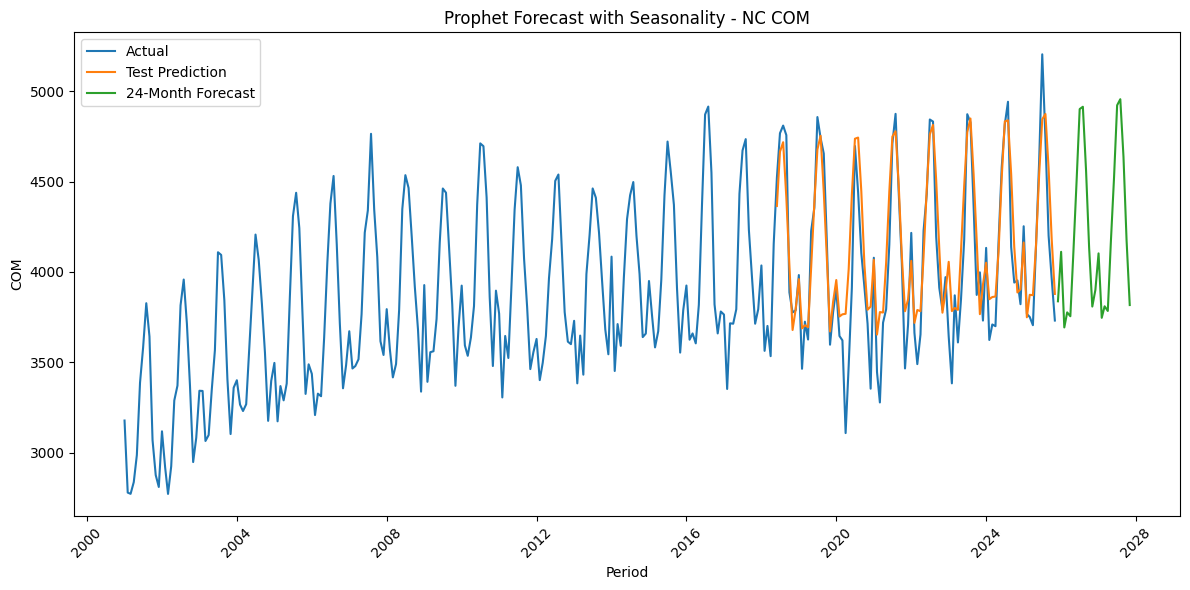

In [44]:
target_col = keep_columns[0]

# version 1
df_model = df.copy()
df_model["period"] = pd.to_datetime(df_model["period"])
df_model = df_model.sort_values("period").reset_index(drop=True)

prophet_df = df_model[["period", target_col]].rename(columns={"period": "ds", target_col: "y"})

# Train/test split (70/30)
split_idx = int(len(prophet_df) * 0.7)
train = prophet_df.iloc[:split_idx].copy()
test = prophet_df.iloc[split_idx:].copy()

# Fit Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive"
)
model.fit(train)

# Predict on test set
test_forecast = model.predict(test[["ds"]])
test[f"predicted_{target_col}"] = test_forecast["yhat"].values

# Metrics
rmse = np.sqrt(mean_squared_error(test["y"], test[f"predicted_{target_col}"]))
r2 = r2_score(test["y"], test[f"predicted_{target_col}"])

print("Test RMSE:", rmse)
print("Test R^2:", r2)

# Refit on full dataset for 24-month forecast
final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.1,
    seasonality_prior_scale=10.0
)
final_model.fit(prophet_df)

future = final_model.make_future_dataframe(periods=24, freq="MS")
forecast = final_model.predict(future)

future_forecast = forecast[forecast["ds"] > prophet_df["ds"].max()][["ds", "yhat"]].copy()
future_forecast = future_forecast.rename(
    columns={"ds": "period", "yhat": f"predicted_{target_col}"}
)
future_forecast["stateid"] = stateid
future_forecast["salesUnit"] = "million kilowatt hours"

print(future_forecast[["period", "stateid", "salesUnit", f"predicted_{target_col}"]])

# Plot
plt.figure(figsize=(12, 6))
plt.plot(prophet_df["ds"], prophet_df["y"], label="Actual")
plt.plot(test["ds"], test[f"predicted_{target_col}"], label="Test Prediction")
plt.plot(
    future_forecast["period"],
    future_forecast[f"predicted_{target_col}"],
    label="24-Month Forecast"
)
plt.xlabel("Period")
plt.ylabel(target_col)
plt.title(f"Prophet Forecast with Seasonality - {stateid} {target_col}")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()